In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import json
import matplotlib.pyplot as plt
import os
from src.utils import reconstruct_trajectory, ideal_trajectory

### Resultados parte A

In [2]:
with open("resultados/parteA.json") as f:
    data_A = json.load(f)

A_a = np.array(data_A["A_a"])
B_a = np.array(data_A["B_a"])
E_a = np.array(data_A["E_a"])
T = np.array(data_A["T"])
psi_ref = np.array(data_A["psi_ref"])

v_A = np.array(data_A["v"])
r_A = np.array(data_A["r"])
psi_A = np.array(data_A["psi"])
xi_A = np.array(data_A["xi"])

error_A = np.array(data_A["error"])
tau_A = np.array(data_A["tau_r"])

metrics_A = data_A["metrics"]

result_A = {
    "name": "PARTE A",
    "T": T,
    "psi_ref": psi_ref,
    "v": v_A,
    "r_yaw": r_A,
    "psi": psi_A,
    "xi": xi_A,
    "error": error_A,
    "tau_r": tau_A,
    "metrics": {
        "name": "PARTE A",
        "max_abs_tau": metrics_A["max_abs_tau"],
        "rms_tau": metrics_A["rms_tau"],
        "max_abs_error": metrics_A["max_abs_error"],
        "iae": metrics_A["iae"],
        "ise": metrics_A["ise"],
        "final_error": metrics_A["final_error"],
        "max_abs_v": metrics_A["max_abs_v"],
        "max_abs_r": metrics_A["max_abs_r"],
        "max_abs_psi": metrics_A["max_abs_psi"]
    }
}

### Resultados parte B

In [3]:
with open("resultados/parteB.json") as f:
    data_B = json.load(f)

X_B = np.array(data_B["X"])
Y_B = np.array(data_B["Y"])

### 1)

Partimos del sistema aumentado de la parte A con un integrador para poder seguir una referencia $\psi_{ref}$:

\begin{align*}
  \dot{\mathbf{x}}_a &= \mathbf{A}_a\mathbf{x}_a + \mathbf{B}_a\tau_r + \mathbf{E}_a\psi_{ref}
\end{align*}

Donde:


$$\mathbf{A}_a = \begin{bmatrix}
  -0.25 & -2 & 0 & 0 \\
  0.08 & -0.35 & 0 & 0 \\
  0 & 1 & 0 & 0 \\
  0 & 0 & -1 & 0
\end{bmatrix}, \quad
\mathbf{B}_a = \begin{bmatrix} 0 \\ 0.62 \\ 0 \\ 0 \end{bmatrix}, \quad
\mathbf{E}_a = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 1 \end{bmatrix} $$



Para el diseño LQI, se busca una ley de control de la forma:

$$
\tau_{r}=-K_{a}x_{a}
$$

con:

$$
K_a=
\begin{bmatrix}
k_v & k_r & k_\psi & k_i
\end{bmatrix}
$$

Por lo tanto:

$$
\tau_r= -k_v v - k_r r - k_\psi \psi - k_i \xi
$$

El objetivo del diseño LQI es encontrar la ganancia $K_a$ que minimice la siguiente función de costo cuadrática:

$$
J=\int_0^\infty \left(x_a^T Q_a x_a + \tau_r^T R \tau_r \right)dt
$$

Como el sistema tiene una única entrada escalar $\tau_r$, la función de costo también puede escribirse como:

$$
J=\int_0^\infty \left(x_a^T Q_a x_a + R\tau_r^2 \right)dt
$$

La matriz $Q_a$ penaliza los estados aumentados del sistema, mientras que $R$ penaliza el esfuerzo de control. Los pesos asociados a $\psi$ y a $xi$ permiten regular la precisión del seguimiento de rumbo y la eliminación del error estacionario, mientras que el valor de $R$ permite limitar la magnitud de la señal de control $\tau_r$.

Una elección posible para $Q_a$, si se trabaja con una matriz diagonal, es:

$$
Q_a=
\begin{bmatrix}
q_v & 0 & 0 & 0\\
0 & q_r & 0 & 0\\
0 & 0 & q_\psi & 0\\
0 & 0 & 0 & q_\xi
\end{bmatrix}
$$

y:

$$
R=
\begin{bmatrix}
r_u
\end{bmatrix}
$$


### 2)

Como se demostró en el ejercicio 4 de la parte A, al calcular el rango de la matriz de controlabilidad del sistema aumentado se obtiene rango completo. Por lo tanto, el sistema aumentado es controlable.

En este caso, esto permite concluir que es posible diseñar un controlador LQI para el sistema aumentado, ya que la acción de control $\tau_r$ puede influir sobre todos los estados del modelo aumentado, incluyendo el estado integral $xi$. La incorporación del integrador permite eliminar el error estacionario frente a referencias constantes de rumbo.

### 3)

In [4]:
casos = {
    "MUY_AGRESIVO": {
        "Q_a": np.diag([1, 1, 80, 150]),
        "R": np.array([[0.5]])
    },
    "AGRESIVO": {
        "Q_a": np.diag([1, 1, 50, 100]),
        "R": np.array([[1]])
    },
    "INTERMEDIO": {
        "Q_a": np.diag([1, 2, 30, 80]),
        "R": np.array([[10]])
    },
    "V_PENALIZADO": {
        "Q_a": np.diag([10, 5, 30, 80]),
        "R": np.array([[10]])
    },
    "SUAVE": {
        "Q_a": np.diag([1, 5, 20, 50]),
        "R": np.array([[50]])
    },
    "CONTROL_ECONOMICO": {
        "Q_a": np.diag([1, 5, 10, 20]),
        "R": np.array([[200]])
    }
}

FALTA JUSTIFICAR LA ELECCION DE VALORES

### 4)

In [5]:
from src.parteC import LQI, get_info, plot_results, print_metrics, plot_poles, colors

In [6]:
Tf = 60

x0 = np.zeros(4)

controllers = {}
results = {}

for name, params in casos.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    controller = LQI(params["Q_a"], params["R"], A_a, B_a, E_a, verbose=True)
    result = get_info(name, controller, T, psi_ref, x0)

    controllers[name] = controller
    results[name] = result


MUY_AGRESIVO
K_a = [[  0.10698547   7.83798091  21.38178715 -17.32050808]]
Polos LQI = [-1.94755064+2.09068248j -1.94755064-2.09068248j -1.31422552+0.j
 -0.25022137+0.j        ]

AGRESIVO
K_a = [[  0.11013662   6.1203464   13.6645729  -10.        ]]
Polos LQI = [-1.43000924+1.66619895j -1.43000924-1.66619895j -1.28425664+0.j
 -0.25033966+0.j        ]

INTERMEDIO
K_a = [[ 0.1206056   3.46619819  5.11688483 -2.82842712]]
Polos LQI = [-0.7219319 +1.06663821j -0.7219319 -1.06663821j -0.25059663+0.j
 -1.05458244+0.j        ]

V_PENALIZADO
K_a = [[ 0.0707173   3.66698644  5.43838461 -2.82842712]]
Polos LQI = [-0.84862213+1.07182788j -0.84862213-1.07182788j -0.92182394+0.j
 -0.2544634 +0.j        ]

SUAVE
K_a = [[ 0.11968432  2.18981755  2.46134807 -1.        ]]
Polos LQI = [-0.47686276+0.76813255j -0.47686276-0.76813255j -0.25225098+0.j
 -0.75171037+0.j        ]

CONTROL_ECONOMICO
K_a = [[ 0.11123634  1.24780666  1.13413165 -0.31622777]]
Polos LQI = [-0.33566985+0.5518008j -0.33566985-0.551

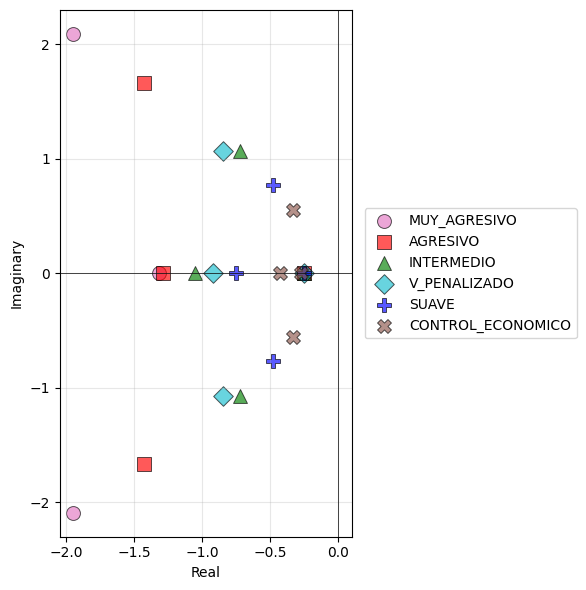

In [7]:
plot_poles(controllers, save=True, save_dir='plots/parteC/lqi')

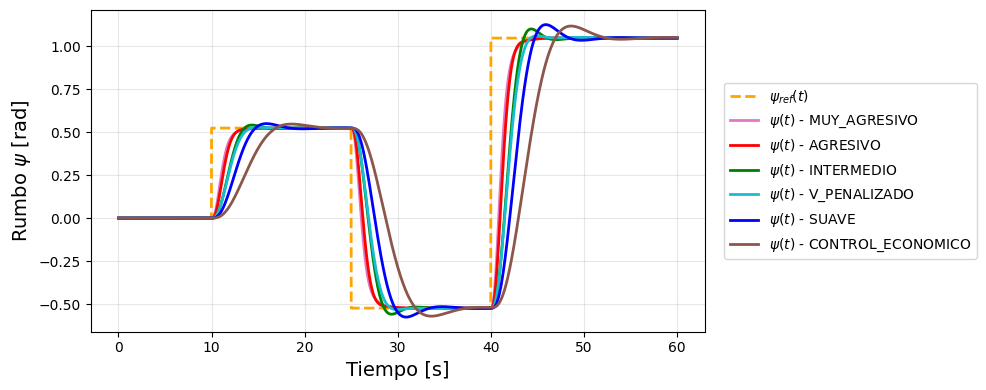

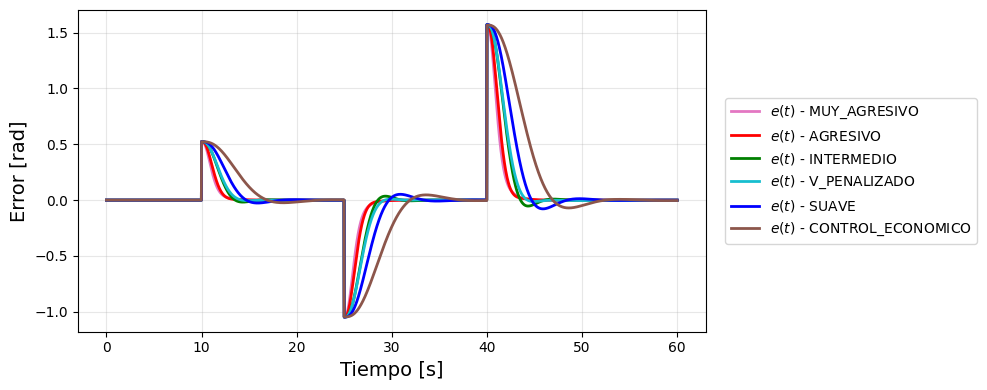

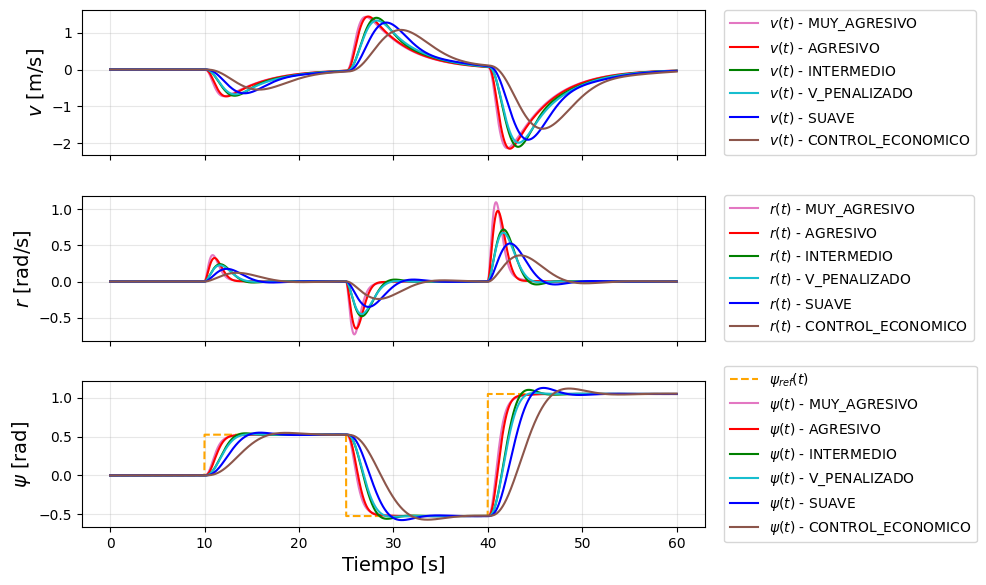

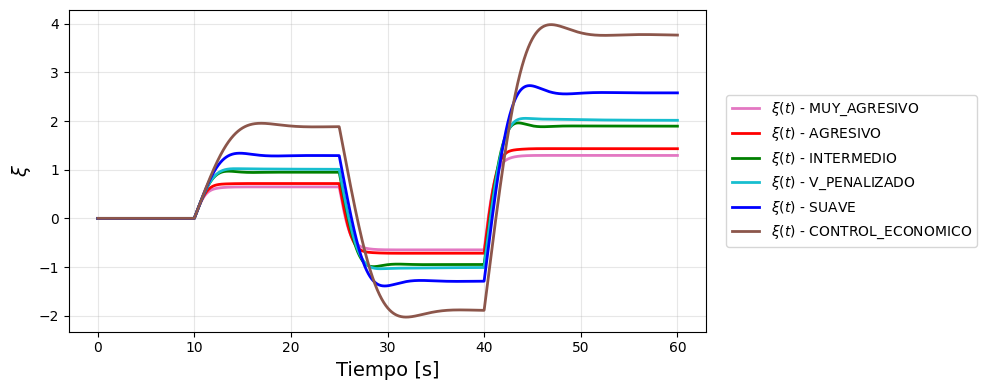

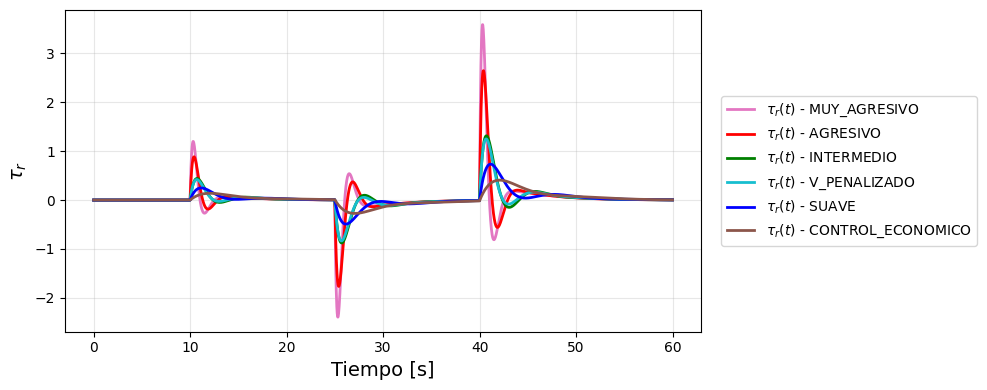

In [8]:
plot_results(results, show=True, save=True, save_dir='plots/parteC/lqi')

### 5)

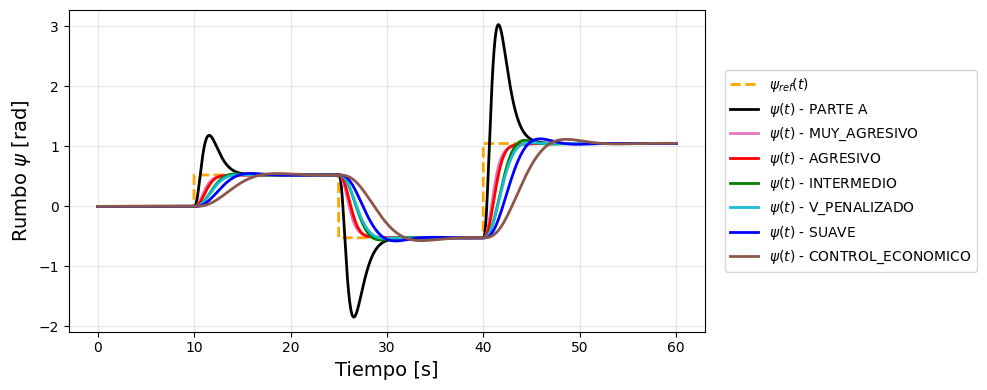

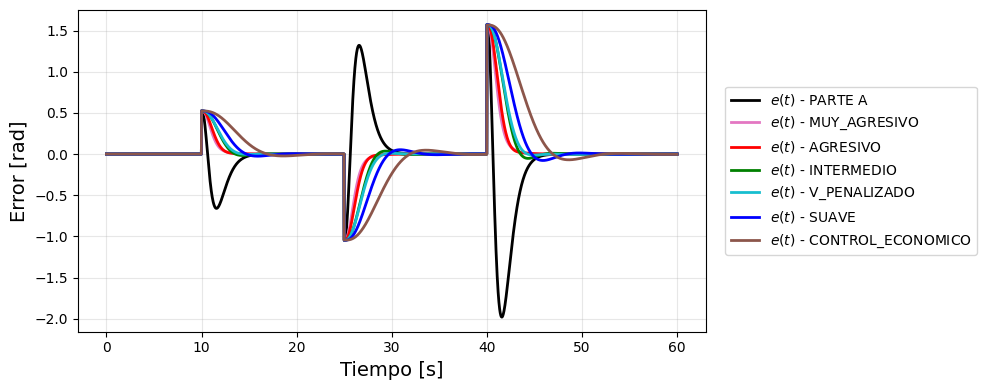

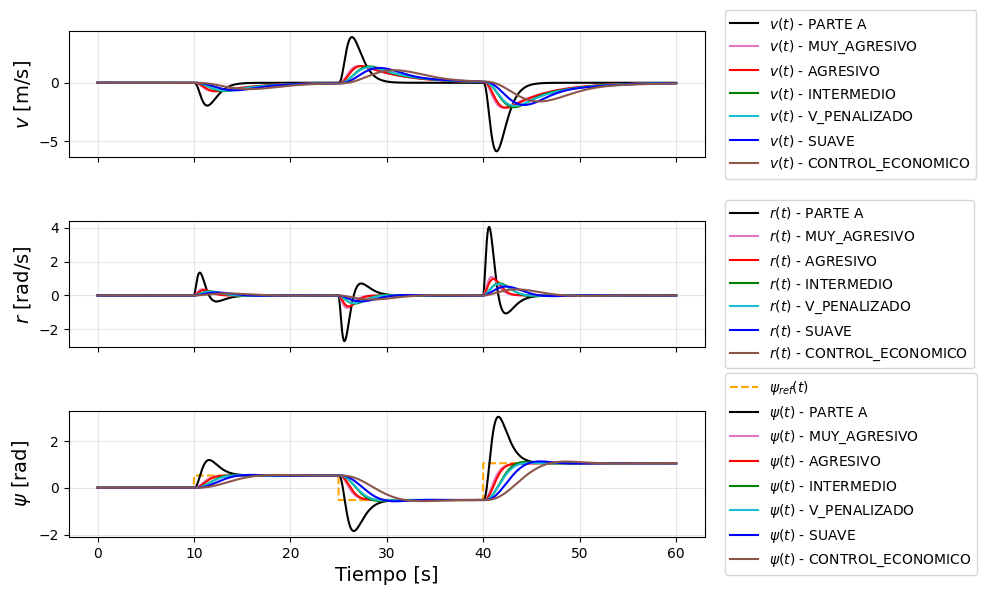

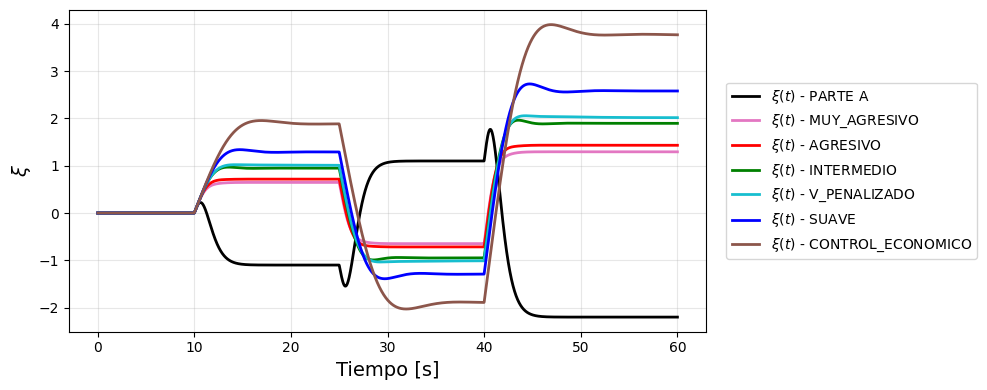

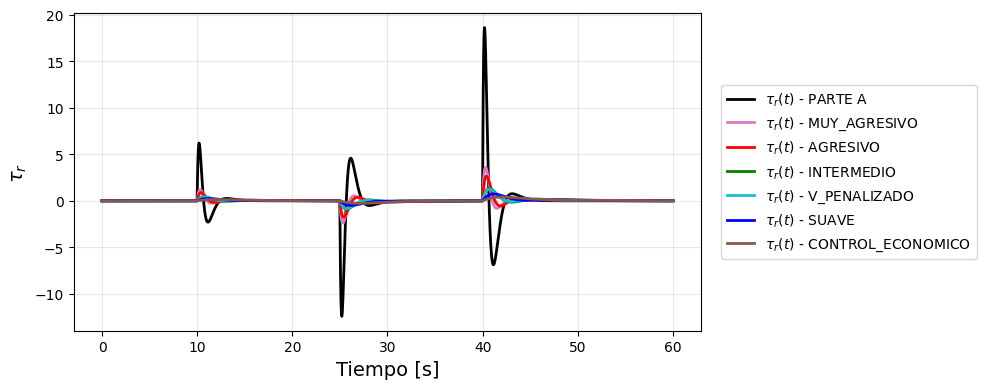

In [9]:
results_comparacion = {"PARTE A": result_A, **results}
plot_results(results_comparacion, show=True, save=True, save_dir='plots/parteC/comparacion')

In [10]:
print_metrics(results_comparacion)

,Controller,Max |tau_r|,RMS tau_r,Max |error|,IAE,ISE,Final error,Max |v|,Max |r|,Max |psi|
0,PARTE A,18.598934,1.907706,1.981027,9.270951,9.829364,-1.449063e-11,5.890279,4.053688,3.028224
1,MUY_AGRESIVO,3.588430484374083,0.4099724364968539,1.570820609223245,3.8826709304104545,3.2644587813898602,-1.274179e-05,2.1372004486211877,1.0952936635116173,1.047387197093261
2,AGRESIVO,2.6467768053993224,0.3396847286317828,1.570840280798321,4.3005536939967515,3.76563740394767,-2.015434e-05,2.150256420074969,0.9749218954572986,1.0475131142612917
3,INTERMEDIO,1.314214493745893,0.22165480402841883,1.5708873601530078,6.013022749802872,5.416473704441984,-3.845324e-05,2.0991414199072183,0.7184772709964362,1.1004181820461971
4,V_PENALIZADO,1.2512820422622044,0.2085299177539983,1.5714902963781023,6.206414338532509,5.582909501355498,-2.919344e-04,1.9879362355013155,0.6740622940503256,1.0597644408963558
5,SUAVE,0.7349084088120938,0.16034772749603562,1.5720319300911072,8.44845620742083,7.554348456883342,-1.072193e-04,1.9057967387032266,0.5258611745826148,1.1255242006530104
6,CONTROL_ECONOMICO,0.40756806527640665,0.12527154838968513,1.5676650964526604,12.219537645715373,11.016228889731064,-3.686059e-03,1.607796144627679,0.3610773021370641,1.1173680429720372


FALTA COMENTAR DIFERENCIAS - TAMBIÉN APARECE EN EL PUNTO 8

### Comparación de trayectorias LQI

Antes de elegir un caso representativo, se comparan las trayectorias reconstruidas para todos los diseños LQI contra la trayectoria ideal.

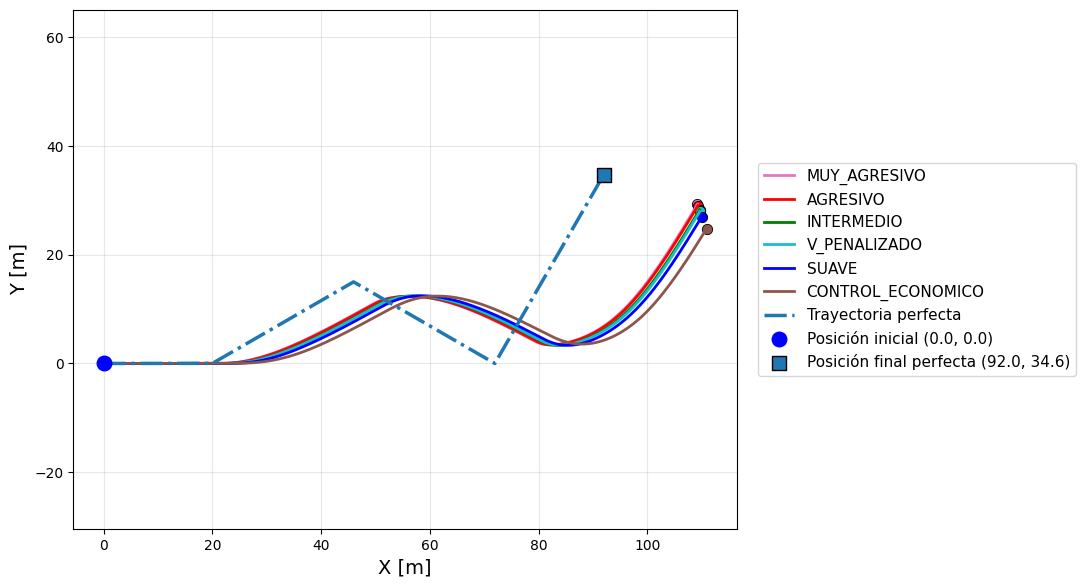

In [11]:
u0 = 2.0

trayectorias_lqi = {}

for name, result in results.items():
    X_i, Y_i = reconstruct_trajectory(result["T"], result["v"], result["psi"], u0=u0)
    trayectorias_lqi[name] = {"T": result["T"], "X": X_i, "Y": Y_i}

# Trayectoria ideal: psi sigue a psi_ref instantaneamente y no hay deriva lateral (v = 0).
X_perfect, Y_perfect = ideal_trajectory(T, psi_ref, u0=u0)

plt.figure(figsize=(11, 6))

for name, trayectoria in trayectorias_lqi.items():
    plt.plot(trayectoria["X"], trayectoria["Y"], linewidth=2, color=colors[name], label=name)
    plt.scatter(trayectoria["X"][-1], trayectoria["Y"][-1], s=55, color=colors[name], edgecolors="black", linewidths=0.6)

plt.plot(X_perfect, Y_perfect, color="tab:blue", linestyle="-.", linewidth=2.5, label="Trayectoria perfecta")
plt.scatter(X_perfect[0], Y_perfect[0], color="blue", s=110, label=f"Posición inicial ({X_perfect[0]:.1f}, {Y_perfect[0]:.1f})", zorder=3)
plt.scatter(X_perfect[-1], Y_perfect[-1], color="tab:blue", s=110, marker="s", edgecolors="black", linewidths=1.0, label=f"Posición final perfecta ({X_perfect[-1]:.1f}, {Y_perfect[-1]:.1f})", zorder=4)

plt.xlabel("X [m]", fontsize=14)
plt.ylabel("Y [m]", fontsize=14)
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.legend(fontsize=11, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()

os.makedirs("plots/parteC/lqi", exist_ok=True)

plt.savefig("plots/parteC/lqi/trayectorias_lqi.png", dpi=300, bbox_inches="tight")
plt.show()

### 6)

Usamos el intermedio

In [12]:
u0 = 2.0

result_C = results["INTERMEDIO"]
trayectoria_C = trayectorias_lqi["INTERMEDIO"]

T_C = trayectoria_C["T"]
X_C = trayectoria_C["X"]
Y_C = trayectoria_C["Y"]

print("Posición inicial Parte C:")
print("X_C(0) =", X_C[0])
print("Y_C(0) =", Y_C[0])

print("Posición final Parte C:")
print("X_C(Tf) =", round(X_C[-1], 4))
print("Y_C(Tf) =", round(Y_C[-1], 4))

Posición inicial Parte C:
X_C(0) = 0.0
Y_C(0) = 0.0
Posición final Parte C:
X_C(Tf) = 109.6128
Y_C(Tf) = 28.2702


### 7)

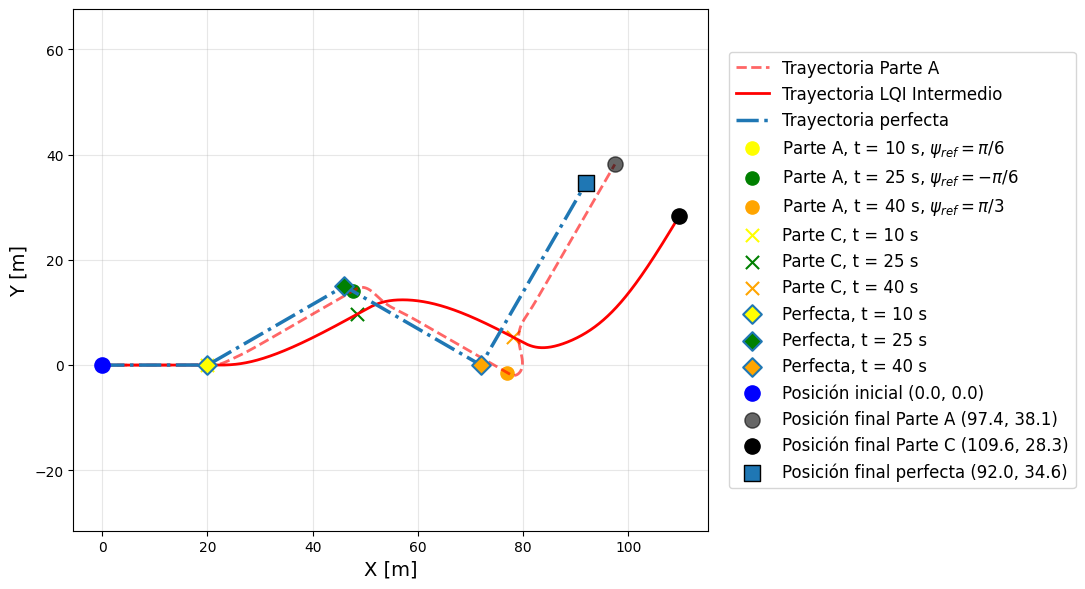

In [13]:
fontsize = 14

idx_10 = np.argmin(np.abs(T - 10))
idx_25 = np.argmin(np.abs(T - 25))
idx_40 = np.argmin(np.abs(T - 40))

# Trayectoria perfecta: psi sigue a psi_ref instantaneamente y no hay deriva lateral (v = 0).
X_perfect, Y_perfect = ideal_trajectory(T, psi_ref, u0=u0, X0=X_B[0], Y0=Y_B[0])


plt.figure(figsize=(11, 6))
plt.plot(X_B, Y_B, color='red', linestyle='--', linewidth=2, label='Trayectoria Parte A', alpha=0.6)
plt.plot(X_C, Y_C, color='red', linewidth=2, label='Trayectoria LQI Intermedio')
plt.plot(X_perfect, Y_perfect, color='tab:blue', linestyle='-.', linewidth=2.5, label='Trayectoria perfecta')


marker_colors = ['yellow', 'green', 'orange']
plt.scatter(X_B[idx_10], Y_B[idx_10], s=90, label=r"Parte A, t = 10 s, $\psi_{ref}=\pi/6$", marker='o', color=marker_colors[0])
plt.scatter(X_B[idx_25], Y_B[idx_25], s=90, label=r"Parte A, t = 25 s, $\psi_{ref}=-\pi/6$", marker='o', color=marker_colors[1])
plt.scatter(X_B[idx_40], Y_B[idx_40], s=90, label=r"Parte A, t = 40 s, $\psi_{ref}=\pi/3$", marker='o', color=marker_colors[2])

plt.scatter(X_C[idx_10], Y_C[idx_10], s=90, label=r"Parte C, t = 10 s", marker='x', color=marker_colors[0])
plt.scatter(X_C[idx_25], Y_C[idx_25], s=90, label=r"Parte C, t = 25 s", marker='x', color=marker_colors[1])
plt.scatter(X_C[idx_40], Y_C[idx_40], s=90, label=r"Parte C, t = 40 s", marker='x', color=marker_colors[2])

plt.scatter(X_perfect[idx_10], Y_perfect[idx_10], s=90, label=r"Perfecta, t = 10 s", marker='D', color=marker_colors[0], edgecolors='tab:blue', linewidths=1.5, zorder=4)
plt.scatter(X_perfect[idx_25], Y_perfect[idx_25], s=90, label=r"Perfecta, t = 25 s", marker='D', color=marker_colors[1], edgecolors='tab:blue', linewidths=1.5, zorder=4)
plt.scatter(X_perfect[idx_40], Y_perfect[idx_40], s=90, label=r"Perfecta, t = 40 s", marker='D', color=marker_colors[2], edgecolors='tab:blue', linewidths=1.5, zorder=4)


plt.scatter(X_B[0], Y_B[0], color='blue', s=120, label=f'Posición inicial ({X_B[0]:.1f}, {Y_B[0]:.1f})', zorder=3)
plt.scatter(X_B[-1], Y_B[-1], color='black', s=120, label=f'Posición final Parte A ({X_B[-1]:.1f}, {Y_B[-1]:.1f})', zorder=3, alpha=0.6)
plt.scatter(X_C[-1], Y_C[-1], color='black', s=120, label=f'Posición final Parte C ({X_C[-1]:.1f}, {Y_C[-1]:.1f})', zorder=3)
plt.scatter(X_perfect[-1], Y_perfect[-1], color='tab:blue', s=120, label=f'Posición final perfecta ({X_perfect[-1]:.1f}, {Y_perfect[-1]:.1f})', marker='s', edgecolors='black', linewidths=1.0, zorder=4)
plt.xlabel('X [m]', fontsize=fontsize)
plt.ylabel('Y [m]', fontsize=fontsize)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend(fontsize=fontsize - 2, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
os.makedirs("plots/parteC/comparacion", exist_ok=True)
plt.savefig("plots/parteC/comparacion/trayectoria_parteA_vs_lqi_intermedio.png", dpi=300, bbox_inches='tight')
plt.show()

### 8)

FALTA DISCUTIR VENTAJAS Y DESVENTAJAS 

Mencionar algo de que en LQI hay que elegir los valores a mano (diseñar) pero permite tunear el resultado final (?)